# Predictive Analysis

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, train_test_split 

import imblearn
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [2]:
tracks_df = pd.read_csv("../datasets/tracks_cleaned.csv")
artists_df = pd.read_csv("../datasets/artists_cleaned.csv")

In [3]:
artists_df['region'].value_counts()

region
Lombardia         31
Campania          12
Lazio             12
Veneto             6
Piemonte           6
Sardegna           4
Liguria            3
Puglia             2
Sicilia            2
Emilia-Romagna     1
Toscana            1
Marche             1
Calabria           1
Name: count, dtype: int64

In [4]:
region_to_class = {
    "Lombardia": "Lombardia",
    "Piemonte": "North",
    "Trentino": "North",
    "Liguria": "North",
    "Veneto":"North",
    "Friuli-Venezia-Giulia": "North",
    "Valle d'Aosta": "North",
    "Emilia-Romagna": "Lazio",
    "Toscana":"Lazio",
    "Abruzzo":"Lazio",
    "Umbria":"Lazio",
    "Lazio":"Lazio",
    "Marche":"Lazio",
    "Molise":"Campania",
    "Campania":"Campania",
    "Sardegna":"South",
    "Basilicata": "South",
    "Puglia": "South",
    "Calabria":"South",
    "Sicilia":"South"
}

In [5]:
# Get all artists name to lower case
artists_df['name_norm'] = artists_df['name'].str.lower()
tracks_df['name_norm'] = tracks_df['name_artist'].str.lower()

In [6]:
artist_to_class = (
    artists_df
    .assign(class_label=lambda df: df['region'].map(region_to_class))
    .set_index('name_norm')['class_label']
    .to_dict()
)
print(artist_to_class)


{'99 posse': 'Campania', 'achille lauro': 'North', 'alfa': nan, 'anna pepe': nan, 'articolo 31': 'Lombardia', 'babaman': 'Lombardia', 'baby k': 'Lazio', 'bassi maestro': 'Lombardia', 'beba': nan, 'bigmama': nan, 'brusco': nan, 'bushwaka': nan, 'caneda': 'Lombardia', 'caparezza': 'South', 'capo plaza': 'Campania', 'chadia rodriguez': 'North', 'clementino': 'Campania', 'club dogo': 'Lombardia', 'coez': 'Campania', 'colle der fomento': 'Lazio', 'cor veleno': 'Lazio', 'dani faiv': 'North', 'dargen d_amico': nan, 'dark polo gang': 'Lazio', 'doll kill': nan, 'don joe': 'Lombardia', 'drefgold': 'Lazio', 'emis killa': 'Lombardia', 'ensi': 'North', 'entics': 'Lombardia', 'ernia': 'Lombardia', 'eva rea': nan, 'fabri fibra': 'Lombardia', 'fedez': 'Lombardia', 'frah quintale': 'Lombardia', 'frankie hi-nrg mc': 'North', 'fred de palma': 'North', 'gemitaiz': 'Lazio', 'geolier': 'Campania', 'ghali': 'Lombardia', 'ghemon': 'Campania', 'grido': 'Lombardia', 'guè pequeno': 'Lombardia', 'hell raton': 'So

In [ ]:
# Manual adjustments
for milano in ['lazza', 'anna pepe']:
    artist_to_class[milano] = 'Lombardia'

for roma in ['coez','achille lauro']:
    artist_to_class[roma] ='Lazio' 

artist_to_class


{'99 posse': 'Campania',
 'achille lauro': 'Lazio',
 'alfa': nan,
 'anna pepe': 'Lombardia',
 'articolo 31': 'Lombardia',
 'babaman': 'Lombardia',
 'baby k': 'Lazio',
 'bassi maestro': 'Lombardia',
 'beba': nan,
 'bigmama': nan,
 'brusco': nan,
 'bushwaka': nan,
 'caneda': 'Lombardia',
 'caparezza': 'South',
 'capo plaza': 'Campania',
 'chadia rodriguez': 'North',
 'clementino': 'Campania',
 'club dogo': 'Lombardia',
 'coez': 'Lazio',
 'colle der fomento': 'Lazio',
 'cor veleno': 'Lazio',
 'dani faiv': 'North',
 'dargen d_amico': nan,
 'dark polo gang': 'Lazio',
 'doll kill': nan,
 'don joe': 'Lombardia',
 'drefgold': 'Lazio',
 'emis killa': 'Lombardia',
 'ensi': 'North',
 'entics': 'Lombardia',
 'ernia': 'Lombardia',
 'eva rea': nan,
 'fabri fibra': 'Lombardia',
 'fedez': 'Lombardia',
 'frah quintale': 'Lombardia',
 'frankie hi-nrg mc': 'North',
 'fred de palma': 'North',
 'gemitaiz': 'Lazio',
 'geolier': 'Campania',
 'ghali': 'Lombardia',
 'ghemon': 'Campania',
 'grido': 'Lombardia',

In [ ]:
tracks_df['class_label'] = tracks_df['name_norm'].map(artist_to_class)
tracks_df['class_label'].unique()

array(['North', nan, 'Lazio', 'Campania', 'Lombardia', 'South'],
      dtype=object)

In [ ]:
# Removing unlabelled songs
tracks_df_clean = tracks_df.dropna(subset=['class_label']).copy()
len(tracks_df_clean['class_label'])

8706

In [10]:
tracks_df_clean['class_label'].value_counts()

class_label
Lombardia    3446
Lazio        1910
North        1282
South        1135
Campania      933
Name: count, dtype: int64

In [11]:
tracks_df_clean['name_artist'].value_counts()
    

name_artist
Mondo Marcio     332
Gemitaiz         324
Fabri Fibra      271
Vacca            263
Bassi Maestro    240
                ... 
Niky Savage       31
La Pina           24
Yung Snapp        22
Roshelle          18
Hell Raton        16
Name: count, Length: 77, dtype: int64

In [12]:
len(tracks_df_clean['name_artist'].value_counts())

77

Creating new features for classification

In [13]:
# loading the lyrics for imputing new features
uncleaned_tracks = pd.read_csv("../datasets/tracks.csv")

tracks_df_clean = tracks_df_clean.merge(
    uncleaned_tracks[['name_artist','title','lyrics']],
    on=['name_artist','title'],
    how='left'
)

In [14]:
from utils import *
threshold = 0

tracks_df_clean['lyrics']= tracks_df_clean['lyrics'].astype('string').str.lower()

tracks_df_clean['region_references'] = tracks_df_clean['lyrics'].fillna("").apply(
    lambda lyrics: detect_region_references(lyrics.split(), threshold)
)
tracks_df_clean['region_references'].unique()

array(['nan', 'Lombardia', 'Campania', 'Lazio', 'North'], dtype=object)

In [15]:
tracks_df_clean['region_references'].value_counts()

region_references
nan          6997
Lombardia     666
Campania      503
Lazio         491
North          53
Name: count, dtype: int64

Training and Validation

In [ ]:
# Defining features useful for classification
classification_features = [
    "swear_IT","swear_EN","year","n_tokens","tokens_per_sent","char_per_tok",
    "lexical_density","avg_token_per_clause","bpm","centroid","rolloff","flux","flatness",
    "spectral_complexity","pitch","loudness","popularity","duration_sec",
    "swear_ratio","aggressiveness","relative_popularity","song_age",
    ]
binary_features = ['explicit','has_collaboration']
categorical_features = ['region_references','release_season']
len(categorical_features)+len(classification_features)+len(binary_features)

26

One-Hot Encoding of Categorical Features

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        (feature, 
         OneHotEncoder(handle_unknown='ignore', drop=None if feature!= 'region_references' else ['nan']), 
         [feature]
         ) for feature in categorical_features
    ],
    remainder='passthrough'
)


X_encoded = ct.fit_transform(tracks_df_clean[categorical_features])
X_encoded= X_encoded.toarray() if hasattr(X_encoded, "toarray") else X_encoded
cat_feature_names = ct.get_feature_names_out()
for i,name in enumerate(cat_feature_names):
    for n in categorical_features: 
        name = name.replace(n+'__', '')
    cat_feature_names[i] = name
X_encoded = pd.DataFrame(X_encoded, columns=cat_feature_names, index=tracks_df_clean.index)
X_encoded = pd.concat([X_encoded,tracks_df_clean[binary_features]],axis=1)
X_encoded['explicit'] = X_encoded['explicit'].astype(int)
X_encoded.head()

,region_references_Campania,region_references_Lazio,region_references_Lombardia,region_references_North,release_season_Fall,release_season_Spring,release_season_Summer,release_season_Winter,explicit,has_collaboration
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0


In [18]:
# Defining a seed for experiments
seed = 42
# Defining the number of fold for the k-fold validation
n_folds = 5
# Defining the metrics 
metrics = ['balanced_accuracy','f1_weighted','accuracy']
refit_metric = 'balanced_accuracy'

Continuous Features

In [19]:
# Separating ground-truth labels from features
y_true = tracks_df_clean['class_label']
# Creating data instances with one hot encoding of region references
X = tracks_df_clean.drop(columns=['class_label'])[classification_features]
X.head()

,swear_IT,swear_EN,year,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,...,flatness,spectral_complexity,pitch,loudness,popularity,duration_sec,swear_ratio,aggressiveness,relative_popularity,song_age
0,1.699042,0.495867,0.890818,911,0.329683,4.170455,0.575284,0.621296,1.777492,0.1858,...,0.8202,25.7148,2311.1779,17.8675,46,3.796566,1.053537,1.115200,7.0,0.940170
1,1.802246,0.496181,0.890818,758,0.173983,4.075251,0.556856,0.733168,1.775444,0.1833,...,0.7842,26.9762,2484.3503,29.4590,39,3.729881,1.310285,1.070894,11.0,0.940170
2,1.428991,0.494171,0.486302,382,0.966411,4.023881,0.534328,-0.074122,1.807485,0.1048,...,0.8764,14.2956,2984.6109,20.5067,47,3.605551,1.963588,0.636895,6.0,1.033726
3,-0.034209,-1.156402,0.683140,429,0.334495,3.922857,0.491429,0.729438,1.735474,0.1421,...,0.8571,36.6951,1572.0499,25.3407,41,3.735816,-0.244316,-0.208720,9.0,0.990909
4,0.470498,-1.156402,0.683140,387,-1.095483,4.160606,0.506061,-0.228610,1.710697,0.1115,...,0.8943,23.0539,1943.1810,25.2680,29,3.762149,0.016942,-0.643765,17.0,0.990909


In [20]:
# Scaling the continuous features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=classification_features, index=tracks_df_clean.index)
X_scaled.head()

,swear_IT,swear_EN,year,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,...,flatness,spectral_complexity,pitch,loudness,popularity,duration_sec,swear_ratio,aggressiveness,relative_popularity,song_age
0,1.683300,1.768257,0.842925,2.239618,0.317775,0.676792,1.319071,0.721503,0.890765,1.858828,...,-1.037444,-0.305927,0.159138,-0.884948,0.647102,0.207701,1.292989,2.250827,-1.351793,-0.409884
1,1.787534,1.768702,0.842925,1.361236,0.117164,0.261605,0.929785,0.846864,0.837733,1.759943,...,-1.726065,-0.144553,0.654229,0.580887,0.276877,-0.109657,1.623249,2.157514,-1.050530,-0.409884
2,1.410552,1.765856,0.425102,-0.797404,1.138168,0.037578,0.453889,-0.057761,1.667287,-1.345058,...,0.037569,-1.766818,2.084447,-0.551201,0.699992,-0.701342,2.463606,1.243472,-1.427109,-0.071835
3,-0.067257,-0.570711,0.628415,-0.527574,0.323977,-0.402990,-0.452361,0.842684,-0.197117,0.130312,...,-0.331608,1.098814,-1.953989,0.060096,0.382656,-0.081408,-0.376464,-0.537474,-1.201161,-0.226544
4,0.442489,-0.570711,0.628415,-0.768699,-1.518478,0.633843,-0.143262,-0.230876,-0.838601,-1.080045,...,0.379967,-0.646344,-0.892945,0.050902,-0.252017,0.043907,-0.040403,-1.453720,-0.598635,-0.226544


In [21]:
# concatenating the scaled and one-hot encoded features to obtain the complete processed data
X_final = pd.concat([X_scaled,X_encoded],axis=1)
X_final.head()

,swear_IT,swear_EN,year,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,...,region_references_Campania,region_references_Lazio,region_references_Lombardia,region_references_North,release_season_Fall,release_season_Spring,release_season_Summer,release_season_Winter,explicit,has_collaboration
0,1.683300,1.768257,0.842925,2.239618,0.317775,0.676792,1.319071,0.721503,0.890765,1.858828,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
1,1.787534,1.768702,0.842925,1.361236,0.117164,0.261605,0.929785,0.846864,0.837733,1.759943,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1
2,1.410552,1.765856,0.425102,-0.797404,1.138168,0.037578,0.453889,-0.057761,1.667287,-1.345058,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
3,-0.067257,-0.570711,0.628415,-0.527574,0.323977,-0.402990,-0.452361,0.842684,-0.197117,0.130312,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1
4,0.442489,-0.570711,0.628415,-0.768699,-1.518478,0.633843,-0.143262,-0.230876,-0.838601,-1.080045,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y_true)
class_names = le.classes_
class_names

array(['Campania', 'Lazio', 'Lombardia', 'North', 'South'], dtype=object)

In [23]:
# Separating the test set from the train-validation set, 20% of data for test set
X_train, X_test, y_train, y_test = train_test_split(X_final,y, 
                                                    test_size=0.2, random_state=seed,
                                                    shuffle=True, stratify=y)
print(f"Number of instances for training: {len(X_train)}, number of instances for testing: {len(X_test)}")

Number of instances for training: 6968, number of instances for testing: 1742


Training and Validating Baseline Models

In [24]:
from scipy.stats import expon, loguniform, randint

# Defining the models and their hyperparameter grids
pipe = Pipeline([('sampling','passthrough'),('model',RidgeClassifier())])
weights = [
    None,
    'balanced'
]
# pass cat features as list to avoid numpy errors
smote = SMOTENC(categorical_features=cat_feature_names.tolist(),random_state=seed)
samplers = [
    RandomOverSampler(random_state=seed), 
    RandomUnderSampler(random_state=seed), 
    smote,
    'passthrough'
]
grids = [
    {
        'sampling': samplers,
        'model':[DecisionTreeClassifier()],
        'model__criterion': ['gini', 'entropy'],
        'model__max_depth': [10,13,15,17,20],
        'model__min_samples_split': randint(3,20),
        'model__min_samples_leaf': randint(1,20),
        'model__max_features': [None, 'sqrt', 'log2'],
        'model__class_weight': weights,
    },
    {
        'sampling': samplers,
        'model':[RidgeClassifier()],
        'model__alpha': loguniform(1e-3, 1e3),
        'model__fit_intercept': [True, False],
        'model__tol': [1e-3, 1e-4],
        'model__solver': ['auto'],
        'model__class_weight':weights
    },
    {
        'sampling': [RandomOverSampler(random_state=seed),RandomUnderSampler(random_state=seed),'passthrough'],
        'model':[KNeighborsClassifier()],
        'model__n_neighbors': randint(2,15),
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean','minkowski'],
        'model__p': [1],      # only used for minkowski
    }

]

In [ ]:
# Defining the validation procedure
stratKFold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

randsearch = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=grids,
    cv = stratKFold,
    n_iter=70,
    n_jobs=5,
    return_train_score=True,
    scoring=metrics,
    refit=refit_metric,
    random_state=seed,
    verbose=3
)

In [26]:
result = randsearch.fit(X_train, y_train)

Fitting 5 folds for each of 70 candidates, totalling 350 fits
[CV 4/5] END model=KNeighborsClassifier(), model__metric=minkowski, model__n_neighbors=14, model__p=1, model__weights=uniform, sampling=passthrough; accuracy: (train=0.601, test=0.512) balanced_accuracy: (train=0.509, test=0.413) f1_weighted: (train=0.582, test=0.484) total time=   0.8s
[CV 5/5] END model=DecisionTreeClassifier(), model__class_weight=None, model__criterion=gini, model__max_depth=13, model__max_features=log2, model__min_samples_leaf=11, model__min_samples_split=13, sampling=passthrough; accuracy: (train=0.559, test=0.430) balanced_accuracy: (train=0.482, test=0.355) f1_weighted: (train=0.545, test=0.413) total time=   0.1s
[CV 4/5] END model=DecisionTreeClassifier(), model__class_weight=balanced, model__criterion=entropy, model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=14, sampling=RandomUnderSampler(random_state=42); accuracy: (train=0.492, test=0.354) balan

In [27]:
print(f"Result: {result.best_score_}, best model: {result.best_estimator_}, best hyperparameters: {result.best_params_}")


Result: 0.46522220559314836, best model: Pipeline(steps=[('sampling', RandomOverSampler(random_state=42)),
                ('model',
                 KNeighborsClassifier(n_neighbors=11, p=1,
                                      weights='distance'))]), best hyperparameters: {'model': KNeighborsClassifier(), 'model__metric': 'minkowski', 'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'distance', 'sampling': RandomOverSampler(random_state=42)}


In [28]:
results_df = pd.DataFrame(result.cv_results_)
models = results_df['param_model'].unique()
cols =['params','mean_train_balanced_accuracy','mean_test_accuracy','mean_test_f1_weighted','mean_test_balanced_accuracy']
for model in models:
    mresults = results_df[results_df['param_model']==model]
    best_model = mresults.loc[mresults['mean_test_balanced_accuracy'].idxmax(), cols]
    print(best_model['params'])
    print(best_model)

{'model': KNeighborsClassifier(), 'model__metric': 'minkowski', 'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'distance', 'sampling': RandomOverSampler(random_state=42)}
params                          {'model': KNeighborsClassifier(), 'model__metr...
mean_train_balanced_accuracy                                                  1.0
mean_test_accuracy                                                       0.423796
mean_test_f1_weighted                                                    0.429093
mean_test_balanced_accuracy                                              0.465222
Name: 44, dtype: object
{'model': DecisionTreeClassifier(), 'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 17, 'model__max_features': None, 'model__min_samples_leaf': 14, 'model__min_samples_split': 18, 'sampling': 'passthrough'}
params                          {'model': DecisionTreeClassifier(), 'model__cl...
mean_train_balanced_accuracy                               

Decision Tree Inspection

In [29]:
from sklearn.metrics import balanced_accuracy_score
# Analysis of relationship with tree depth and training error
depths = range(2, 30)
train_errors = []
val_errors = []
min_val = float('inf')
best_tree = None
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
X_train_arr = np.array(X_train)
y_train_arr= np.array(y_train)

for depth in depths:
    tr_error = []
    vl_error = []
    for train_idx, val_idx in cv.split(X_train_arr, y_train_arr):
        XX_train, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
        yy_train, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

        tree = DecisionTreeClassifier(criterion='entropy',
                                      max_depth=depth,min_samples_leaf=16, 
                                      class_weight='balanced', min_samples_split=7,
                                      random_state=42)
        tree.fit(XX_train,yy_train)
        yy_tr_pred = tree.predict(XX_train)
        tr_error.append(1 - balanced_accuracy_score(yy_train, yy_tr_pred))  
        
        y_val_pred = tree.predict(X_val)
        validation = 1- balanced_accuracy_score(y_val,y_val_pred)
        if validation < min_val:
            min_val = validation
            best_tree = tree
        vl_error.append(validation)


    train_errors.append(np.mean(tr_error))
    val_errors.append(np.mean(vl_error))

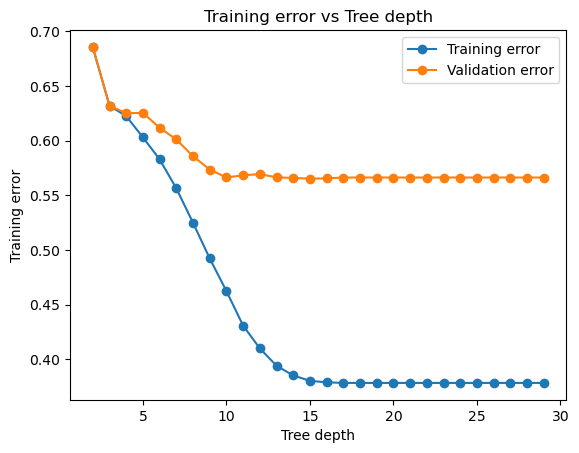

In [30]:
plt.plot(depths, train_errors, marker='o', label='Training error')
plt.plot(depths, val_errors, marker='o', label='Validation error')
plt.xlabel('Tree depth')       
plt.ylabel('Training error')   
plt.title('Training error vs Tree depth')
plt.legend()
plt.show()

In [31]:
tree = best_tree 
feature_names = X_final.columns.tolist() 
print(feature_names)

print(export_text(tree, feature_names=feature_names))

['swear_IT', 'swear_EN', 'year', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'popularity', 'duration_sec', 'swear_ratio', 'aggressiveness', 'relative_popularity', 'song_age', 'region_references_Campania', 'region_references_Lazio', 'region_references_Lombardia', 'region_references_North', 'release_season_Fall', 'release_season_Spring', 'release_season_Summer', 'release_season_Winter', 'explicit', 'has_collaboration']
|--- region_references_Campania <= 0.50
|   |--- region_references_Lazio <= 0.50
|   |   |--- song_age <= 0.50
|   |   |   |--- explicit <= 0.50
|   |   |   |   |--- duration_sec <= -0.40
|   |   |   |   |   |--- swear_ratio <= -0.35
|   |   |   |   |   |   |--- release_season_Spring <= 0.50
|   |   |   |   |   |   |   |--- pitch <= -0.28
|   |   |   |   |   |   |   |   |--- spectral_complexity <= -0.32
|   |   |   |   |   |   |   |   

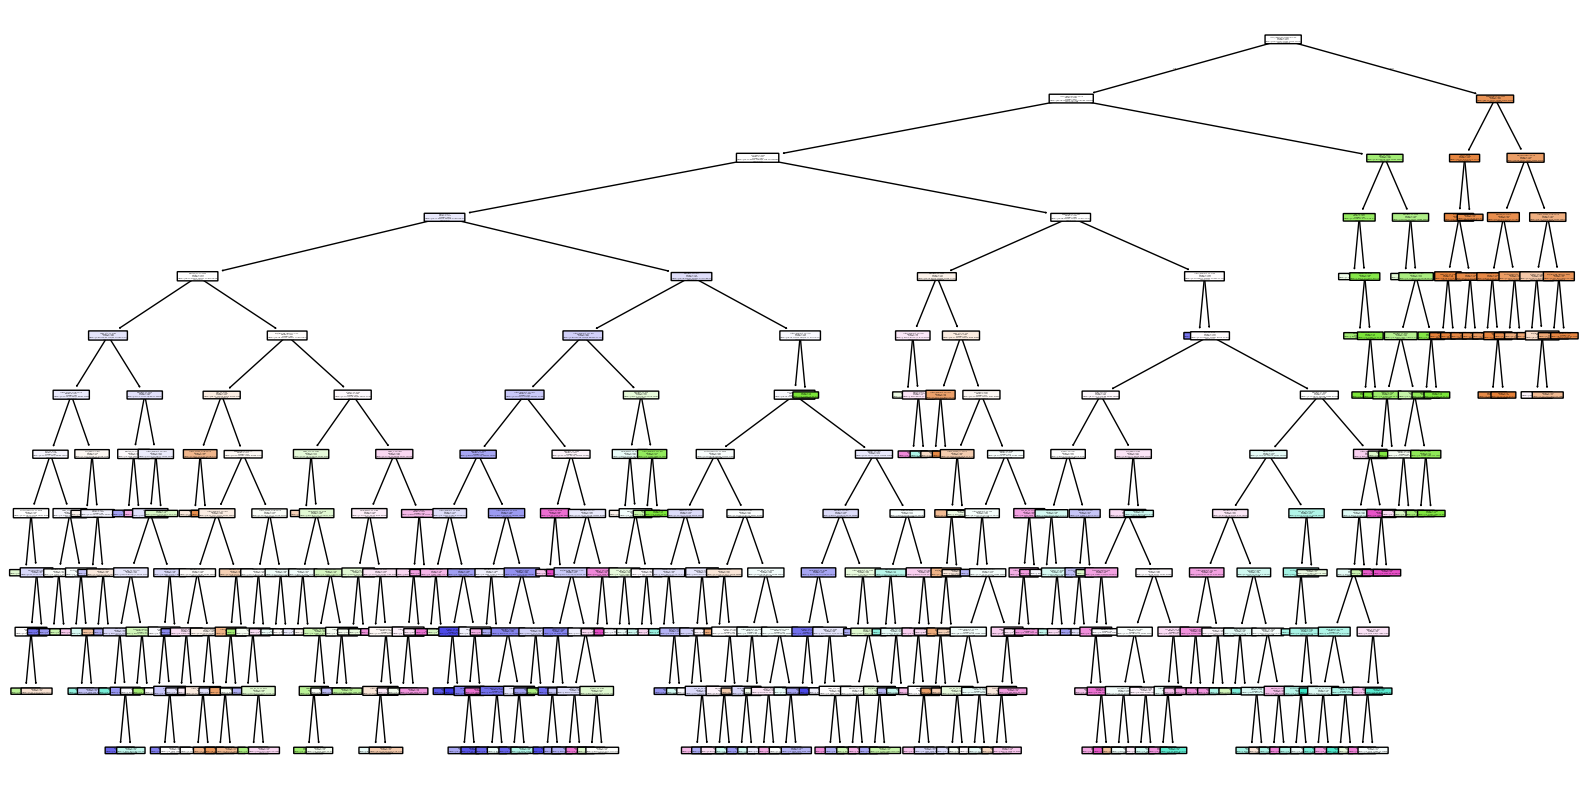

In [32]:
plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=le.classes_,   
    filled=True,
    rounded=True
)
plt.show()

In [33]:
importances = pd.Series(tree.feature_importances_, index=feature_names)
importances.sort_values(ascending=False)

region_references_Campania     0.161834
relative_popularity            0.109007
popularity                     0.100455
song_age                       0.075113
region_references_Lazio        0.048595
loudness                       0.045550
aggressiveness                 0.037870
n_tokens                       0.036629
flux                           0.032529
swear_ratio                    0.029554
year                           0.027742
explicit                       0.025536
duration_sec                   0.025489
char_per_tok                   0.025188
rolloff                        0.024321
spectral_complexity            0.022207
avg_token_per_clause           0.022188
flatness                       0.021548
centroid                       0.019336
lexical_density                0.017903
bpm                            0.017343
pitch                          0.017063
has_collaboration              0.013830
release_season_Spring          0.012720
swear_IT                       0.011177


Training and evaluating Complex Models

In [ ]:
import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from interpret.glassbox import ExplainableBoostingClassifier

# Defining the complex models and their hyperparameter grids
pipe = Pipeline([('sampling','passthrough'),('model',lgb.LGBMClassifier())])

grids = [
    {   
        'sampling':samplers,
        'model':[lgb.LGBMClassifier(objective='multiclass',n_jobs=1,random_state=seed,verbose=-1)],
        'model__num_leaves': randint(20,100),
        'model__max_depth': [-1,5,10,20],
        'model__learning_rate': loguniform(1e-3, 0.2),
        'model__n_estimators': randint(200,1500),
        'model__min_child_samples': randint(1,30),
        'model__subsample': [0.7,0.8,1.0],
        'model__class_weight':['balanced',None],
        'model__min_gain_to_split':[0.0],
        'model__colsample_bytree':[0.9]
    },
    {   
        'sampling':samplers,
        'model':[SVC(random_state=seed)],
        'model__kernel': ['rbf'],
        "model__gamma": ["scale", "auto"],
        'model__decision_function_shape':['ovo'],
        'model__C': loguniform(1e-3, 1e2),
        'model__class_weight':[None,'balanced']     
    },
    {
        'sampling':samplers,
        'model':[RandomForestClassifier(random_state=seed, n_jobs=1)],
        'model__n_estimators': randint(150,800),
        'model__criterion': ['entropy'],
        'model__max_depth': [5,10],          
        'model__min_samples_split': randint(2,7),         
        'model__min_samples_leaf': randint(1,7),           
        'model__max_features': ['sqrt'],        
        'model__class_weight': [None,'balanced'],
        'model__bootstrap':[True]  
    },
    {
        'sampling':['passthrough'],
        'model': [ExplainableBoostingClassifier(random_state=seed,n_jobs=1, feature_names=feature_names, interactions=0)],
        'model__learning_rate': loguniform(1e-3, 0.1),
        'model__max_bins': randint(64,164),
        'model__max_leaves': randint(3,10),
        'model__min_samples_leaf': randint(2,8),
        "model__outer_bags": [8,14],
        "model__inner_bags": [0],
        'model__interactions': randint(2,10)
    }

]

In [35]:
results = []
for param_dist in grids[:-1]:
    randsearch = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        cv = stratKFold,
        n_iter=5,
        n_jobs=5,
        return_train_score = True,
        scoring = metrics,
        refit=refit_metric,
        verbose=3 
        )
    print(f"Model: {param_dist['model']}, starting cv search")
    result = randsearch.fit(X_train,y_train)
    print("="*50)
    print(f"Model: {param_dist['model']}, done")
    results.append(result)

Model: [LGBMClassifier(n_jobs=1, objective='multiclass', random_state=42, verbose=-1)], starting cv search
Fitting 5 folds for each of 5 candidates, totalling 25 fits

[CV 4/5] END model=RidgeClassifier(), model__alpha=2.19183357239061, model__class_weight=None, model__fit_intercept=False, model__solver=auto, model__tol=0.0001, sampling=SMOTENC(categorical_features=['region_references_Campania',
                              'region_references_Lazio',
                              'region_references_Lombardia',
                              'region_references_North', 'release_season_Fall',
                              'release_season_Spring', 'release_season_Summer',
                              'release_season_Winter'],
        random_state=42); accuracy: (train=0.419, test=0.391) balanced_accuracy: (train=0.444, test=0.421) f1_weighted: (train=0.423, test=0.395) total time=   2.9s
[CV 2/5] END model=RidgeClassifier(), model__alpha=0.0038287672160557873, model__class_weight=balanced

In [41]:
# separating the search for the EBM because it is the slowest one
param_dist=grids[-1]
randsearch = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    cv = stratKFold,
    n_iter=3,
    n_jobs=5,
    return_train_score = True,
    scoring = metrics,
    refit=refit_metric,
    verbose=3 
    )
print(f"Model: {param_dist['model']}, starting cv search")
result = randsearch.fit(X_train,y_train)
print("="*50)
print(f"Model: {param_dist['model']}, done")
results.append(result)

Model: [ExplainableBoostingClassifier(feature_names=['swear_IT', 'swear_EN', 'year',
                                             'n_tokens', 'tokens_per_sent',
                                             'char_per_tok', 'lexical_density',
                                             'avg_token_per_clause', 'bpm',
                                             'centroid', 'rolloff', 'flux',
                                             'flatness', 'spectral_complexity',
                                             'pitch', 'loudness', 'popularity',
                                             'duration_sec', 'swear_ratio',
                                             'aggressiveness',
                                             'relative_popularity', 'song_age',
                                             'region_references_Campania',
                                             'region_references_Lazio',
                                             'region_references_Lombardia',
     

/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For mult

[CV 1/5] END model=ExplainableBoostingClassifier(feature_names=['swear_IT', 'swear_EN', 'year',
                                             'n_tokens', 'tokens_per_sent',
                                             'char_per_tok', 'lexical_density',
                                             'avg_token_per_clause', 'bpm',
                                             'centroid', 'rolloff', 'flux',
                                             'flatness', 'spectral_complexity',
                                             'pitch', 'loudness', 'popularity',
                                             'duration_sec', 'swear_ratio',
                                             'aggressiveness',
                                             'relative_popularity', 'song_age',
                                             'region_references_Campania',
                                             'region_references_Lazio',
                                             'region_references_Lombar

/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(


[CV 3/5] END model=ExplainableBoostingClassifier(feature_names=['swear_IT', 'swear_EN', 'year',
                                             'n_tokens', 'tokens_per_sent',
                                             'char_per_tok', 'lexical_density',
                                             'avg_token_per_clause', 'bpm',
                                             'centroid', 'rolloff', 'flux',
                                             'flatness', 'spectral_complexity',
                                             'pitch', 'loudness', 'popularity',
                                             'duration_sec', 'swear_ratio',
                                             'aggressiveness',
                                             'relative_popularity', 'song_age',
                                             'region_references_Campania',
                                             'region_references_Lazio',
                                             'region_references_Lombar

In [43]:
for result in results:
    print(f"Model: {result.best_estimator_}")
    df = pd.DataFrame(result.cv_results_)
    cols = ['mean_test_balanced_accuracy','mean_test_f1_weighted','mean_test_accuracy']
    print(f"{df[cols]}")

Model: Pipeline(steps=[('sampling',
                 SMOTENC(categorical_features=['region_references_Campania',
                                               'region_references_Lazio',
                                               'region_references_Lombardia',
                                               'region_references_North',
                                               'release_season_Fall',
                                               'release_season_Spring',
                                               'release_season_Summer',
                                               'release_season_Winter'],
                         random_state=42)),
                ('model',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.9,
                                learning_rate=np.float64(0.0915187768940778),
                                max_depth=10, min_child_samples=6,
                                min_gain_to_split=0.0, n_estimators=1385,
      

In [70]:
ebm_pgrid={
    'sampling':['passthrough'],
    'model': [ExplainableBoostingClassifier(random_state=seed,n_jobs=1, feature_names=feature_names)],
    'model__learning_rate': [0.1],
    'model__max_bins': [128],
    'model__max_leaves': [3],
    'model__min_samples_leaf': [5],
    'model__interactions': [7,8]
}


gridsearch = GridSearchCV(
    estimator = pipe,
    param_grid = ebm_pgrid,
    cv=stratKFold,
    refit=refit_metric,
    scoring=metrics,
    return_train_score=True,
    n_jobs=5,
    verbose=3
)

ebm_result = gridsearch.fit(X_train,y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(
/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:1249: UserWarning: For mult

[CV 4/5] END model=ExplainableBoostingClassifier(feature_names=['swear_IT', 'swear_EN', 'year',
                                             'n_tokens', 'tokens_per_sent',
                                             'char_per_tok', 'lexical_density',
                                             'avg_token_per_clause', 'bpm',
                                             'centroid', 'rolloff', 'flux',
                                             'flatness', 'spectral_complexity',
                                             'pitch', 'loudness', 'popularity',
                                             'duration_sec', 'swear_ratio',
                                             'aggressiveness',
                                             'relative_popularity', 'song_age',
                                             'region_references_Campania',
                                             'region_references_Lazio',
                                             'region_references_Lombar

In [71]:
print(ebm_result.best_score_)
print(ebm_result.best_params_)
rdf = pd.DataFrame(ebm_result.cv_results_)

0.6347485961590623
{'model': ExplainableBoostingClassifier(feature_names=['swear_IT', 'swear_EN', 'year',
                                             'n_tokens', 'tokens_per_sent',
                                             'char_per_tok', 'lexical_density',
                                             'avg_token_per_clause', 'bpm',
                                             'centroid', 'rolloff', 'flux',
                                             'flatness', 'spectral_complexity',
                                             'pitch', 'loudness', 'popularity',
                                             'duration_sec', 'swear_ratio',
                                             'aggressiveness',
                                             'relative_popularity', 'song_age',
                                             'region_references_Campania',
                                             'region_references_Lazio',
                                             'region_referen

In [72]:
rdf[['param_model','mean_test_balanced_accuracy','mean_test_f1_weighted','mean_test_accuracy']].head()

,param_model,mean_test_balanced_accuracy,mean_test_f1_weighted,mean_test_accuracy
0,ExplainableBoostingClassifier(feature_names=['...,0.634749,0.669817,0.673364
1,ExplainableBoostingClassifier(feature_names=['...,0.625789,0.662654,0.666618


Final model and test set score

In [73]:
from sklearn.metrics import balanced_accuracy_score

final_model = ebm_result.best_estimator_

y_pred = final_model.predict(X_test)
print(f"Final balanced accuracy test score: {balanced_accuracy_score(y_test,y_pred)}")

Final balanced accuracy test score: 0.6250747654952016


In [74]:
from sklearn.metrics import accuracy_score, f1_score
print(f"Final accuracy test score: {accuracy_score(y_test,y_pred)}")
print(f"Final F1 test score: {f1_score(y_test,y_pred,average='weighted')}")

Final accuracy test score: 0.6618828932261768
Final F1 test score: 0.6599146975772245


In [75]:
from interpret import show
ebm = final_model['model']
global_exp = ebm.explain_global()
show(global_exp)


/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning:

Dropping term year & popularity from explanation since we can't graph multinomial interactions.

/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning:

Dropping term year & relative_popularity from explanation since we can't graph multinomial interactions.

/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning:

Dropping term year & explicit from explanation since we can't graph multinomial interactions.

/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning:

Dropping term popularity & relative_popularity from explanation since we can't graph multinomial interactions.

/home/r/miniconda3/envs/dmenv/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2203: UserWarning:

Dropping term popularity & song_age

<!-- http://127.0.0.1:7001/134208787124560/ -->

In [76]:
ebm_local = ebm.explain_local(X_test, y_test)
show(ebm_local)

<!-- http://127.0.0.1:7001/134208758888848/ -->

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report 
print(classification_report(y_test,y_pred,target_names=class_names))

              precision    recall  f1-score   support

    Campania       0.70      0.53      0.61       187
       Lazio       0.73      0.61      0.66       382
   Lombardia       0.66      0.76      0.71       689
       North       0.58      0.63      0.61       257
       South       0.64      0.59      0.61       227

    accuracy                           0.66      1742
   macro avg       0.66      0.63      0.64      1742
weighted avg       0.67      0.66      0.66      1742



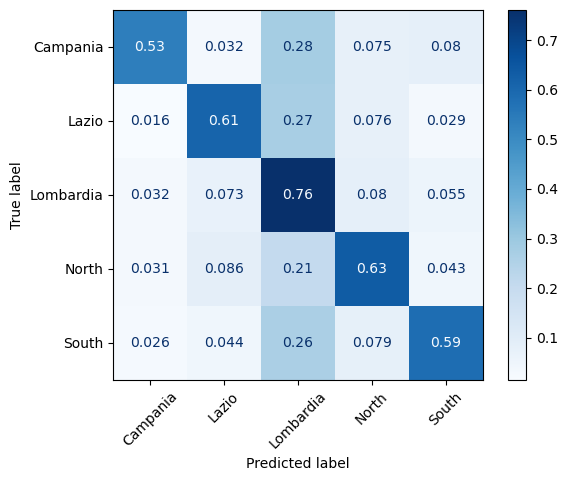

In [78]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap='Blues', xticks_rotation=45)